# Analiza Pinguins dataseta

## Pitanje koje rješavamo
**Možemo li pomoću mjerenja tijela pingvina razlikovati vrste pingvina i koje mjere najviše pomažu u toj razlici?**

Dataset URL: https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv

*Odgovoriti na pitanje koristeci Pandas, NumPy i Matplotlib ili Pandas.plot() funkciju*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'

# !!!Koristimo online verziju dataseta!!!
pinguins_df = pd.read_csv(url)
pinguins_df

# Offline verzija dataseta, nakon sto smo snimili csv lokalno.
# pinguins_df = pd.read_csv('data/pinguins.csv')
# pinguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [6]:
pinguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [7]:
pinguins_df.shape

(344, 8)

In [8]:
pinguins_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [9]:
pinguins_df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [10]:
pinguins_df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Stupci koje cemo koristiti:
- species
- bill_length_mm
- bill_depth_mm
- flipper_length_mm
- body_mass_g
- sex

In [17]:
pd.DataFrame.dropna?

Signature:
pd.DataFrame.dropna(
    self,
    *,
    axis: 'Axis' = 0,
    how: 'AnyAll | lib.NoDefault' = <no_default>,
    thresh: 'int | lib.NoDefault' = <no_default>,
    subset: 'IndexLabel | AnyArrayLike | None' = None,
    inplace: 'bool' = False,
    ignore_index: 'bool' = False,
) -> 'DataFrame | None'
Docstring:
Remove missing values.

See the :ref:`User Guide <missing_data>` for more on which values are
considered missing, and how to work with missing data.

Parameters
----------
axis : {0 or 'index', 1 or 'columns'}, default 0
    Determine if rows or columns which contain missing values are
    removed.

    * 0, or 'index' : Drop rows which contain missing values.
    * 1, or 'columns' : Drop columns which contain missing value.

    Only a single axis is allowed.

how : {'any', 'all'}, default 'any'
    Determine if row or column is removed from DataFrame, when we have
    at least one NA or all NA.

    * 'any' : If any NA values are present, drop that row or column.
  

In [20]:
required_columns = [
    'species',
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'sex'
]

# Izbrisi redtke u kojima ima praznih vrijednosti, ali samo za podskup kolona koje su navedene u listi iznad.
clean_df = pinguins_df.dropna(subset=required_columns).copy()
clean_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [21]:
clean_df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

Koliko pingvina imamo po svakoj vrsti?

In [23]:
species_counts = clean_df['species'].value_counts()
species_counts

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

(array([0, 1, 2]),
 [Text(0, 0, 'Adelie'), Text(1, 0, 'Gentoo'), Text(2, 0, 'Chinstrap')])

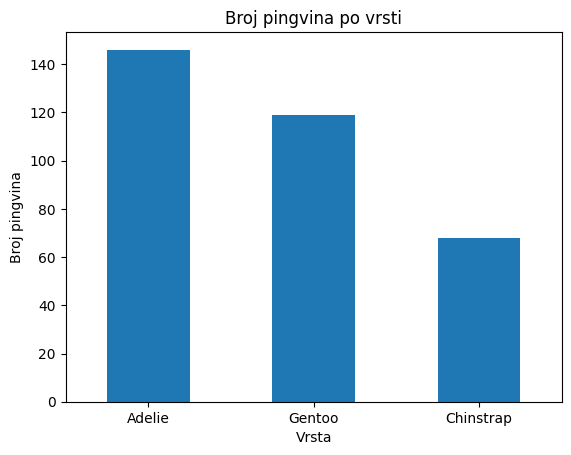

In [29]:
species_counts.plot(
    kind='bar',
    xlabel='Vrsta',
    ylabel='Broj pingvina',
    title='Broj pingvina po vrsti'
)

plt.xticks(rotation=0)

In [30]:
numerical_columns = [
    'bill_length_mm',
    'bill_depth_mm', 
    'flipper_length_mm', 
    'body_mass_g'
]

species_means = clean_df.groupby('species')[numerical_columns].mean()
species_means

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


(array([0, 1, 2]),
 [Text(0, 0, 'Adelie'), Text(1, 0, 'Chinstrap'), Text(2, 0, 'Gentoo')])

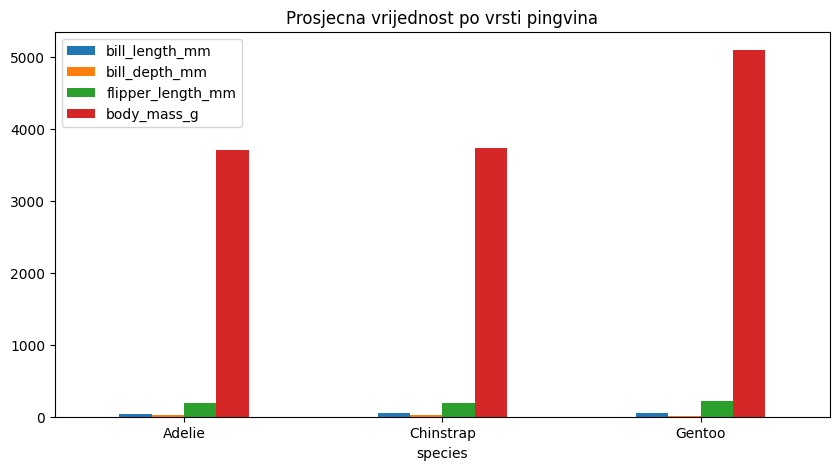

In [32]:
species_means.plot(
    kind='bar',
    title='Prosjecna vrijednost po vrsti pingvina',
    figsize=(10, 5)
)

plt.xticks(rotation=0)

Razlika u vrijednostima zbog toga sto prikazujemo grame i milimetre zajedno pa su vrijednosti u gramima u ovom slucaju oko sto puta vece od vrijednosti u milimetrima.

Ovo cemo rijesiti standardizacijom:

`standardizina_vrijednost = (vrijednost - prosjek) / standardna_devijacija`

In [35]:
measurements = clean_df[numerical_columns].to_numpy()
measurements

array([[  39.1,   18.7,  181. , 3750. ],
       [  39.5,   17.4,  186. , 3800. ],
       [  40.3,   18. ,  195. , 3250. ],
       ...,
       [  49.6,   18.2,  193. , 3775. ],
       [  50.8,   19. ,  210. , 4100. ],
       [  50.2,   18.7,  198. , 3775. ]], shape=(333, 4))

In [44]:
means = np.mean(measurements, axis=0)
stds = np.std(measurements, axis=0)

standardized = (measurements - means) / stds
standardized = np.absolute(standardized)

standardized[:5]

array([[0.89604189, 0.7807321 , 1.42675157, 0.56847478],
       [0.82278787, 0.11958397, 1.06947358, 0.50628618],
       [0.67627982, 0.42472926, 0.42637319, 1.1903608 ],
       [1.33556603, 1.0858774 , 0.56928439, 0.94160639],
       [0.85941488, 1.74702554, 0.78365118, 0.69285199]])

In [45]:
standardized_df = pd.DataFrame(
    standardized,
    columns=[col + '_std' for col in numerical_columns],
    index=clean_df.index
)

# standardized_df
analysis_df = pd.concat([clean_df, standardized_df], axis=1)
analysis_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_length_mm_std,bill_depth_mm_std,flipper_length_mm_std,body_mass_g_std
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,0.896042,0.780732,1.426752,0.568475
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,0.822788,0.119584,1.069474,0.506286
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,0.676280,0.424729,0.426373,1.190361
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,1.335566,1.085877,0.569284,0.941606
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,0.859415,1.747026,0.783651,0.692852


In [46]:
standardized_columns = [col + '_std' for col in numerical_columns]

standardized_means = analysis_df.groupby('species')[standardized_columns].mean()
standardized_means

,bill_length_mm_std,bill_depth_mm_std,flipper_length_mm_std,body_mass_g_std
species,,,,
Adelie,0.960731,0.690870,0.800028,0.719357
Chinstrap,0.934806,0.712127,0.505383,0.657207
Gentoo,0.706134,1.105017,1.162463,1.108219


(array([0, 1, 2]),
 [Text(0, 0, 'Adelie'), Text(1, 0, 'Chinstrap'), Text(2, 0, 'Gentoo')])

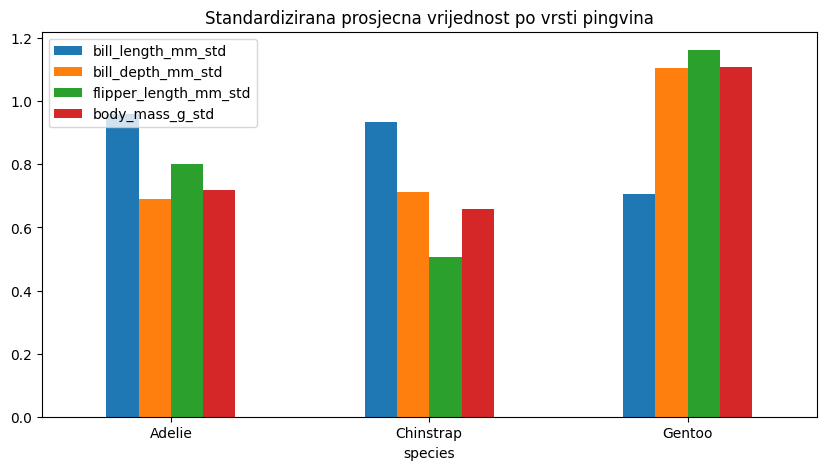

In [48]:
standardized_means.plot(
    kind='bar',
    title='Standardizirana prosjecna vrijednost po vrsti pingvina',
    figsize=(10, 5)
)

plt.xticks(rotation=0)

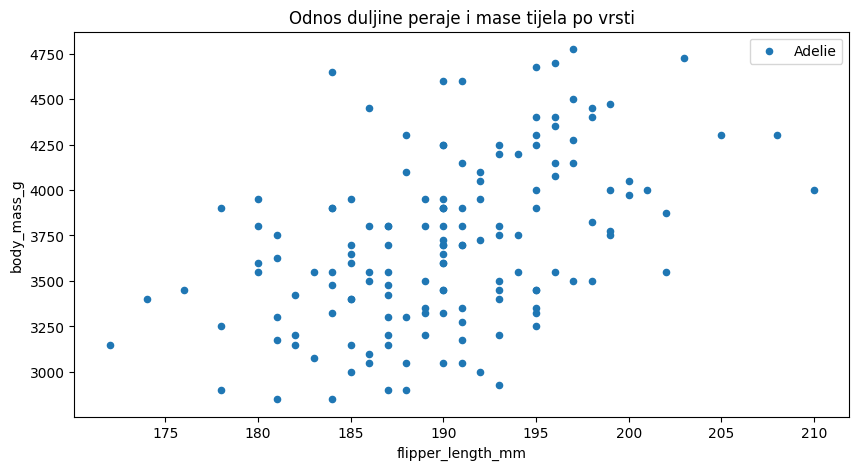

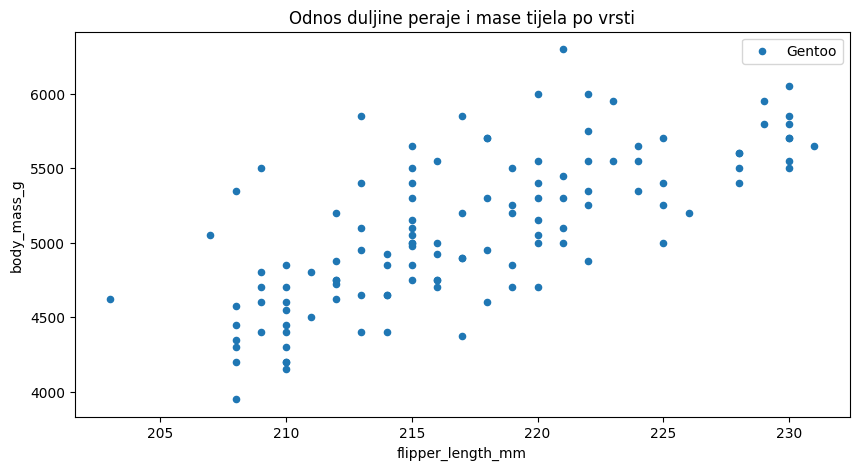

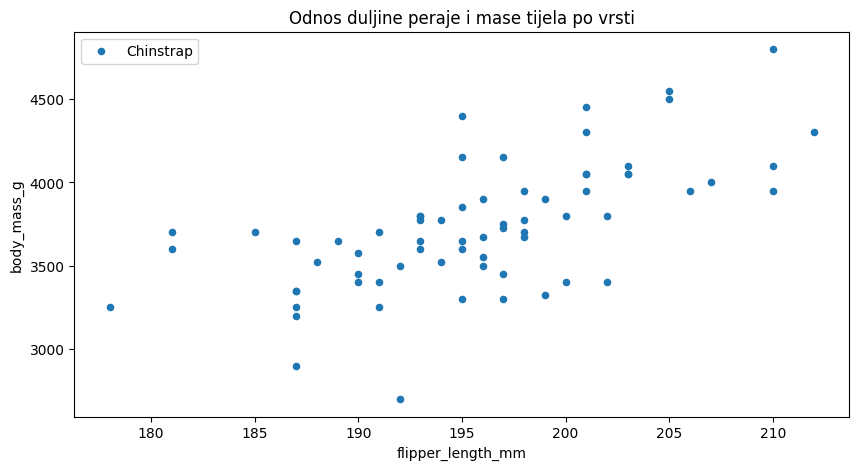

In [50]:
for species in analysis_df.species.unique():
    subset = analysis_df[analysis_df['species'] == species]
    subset.plot.scatter(
        x='flipper_length_mm',
        y='body_mass_g',
        label=species,
        figsize=(10, 5),
        title='Odnos duljine peraje i mase tijela po vrsti'
    )



In [52]:
correlation_matrix = clean_df[numerical_columns].corr()
correlation_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


(array([0, 1, 2, 3]),
 [Text(0, 0, 'bill_length_mm'),
  Text(1, 0, 'bill_depth_mm'),
  Text(2, 0, 'flipper_length_mm'),
  Text(3, 0, 'body_mass_g')])

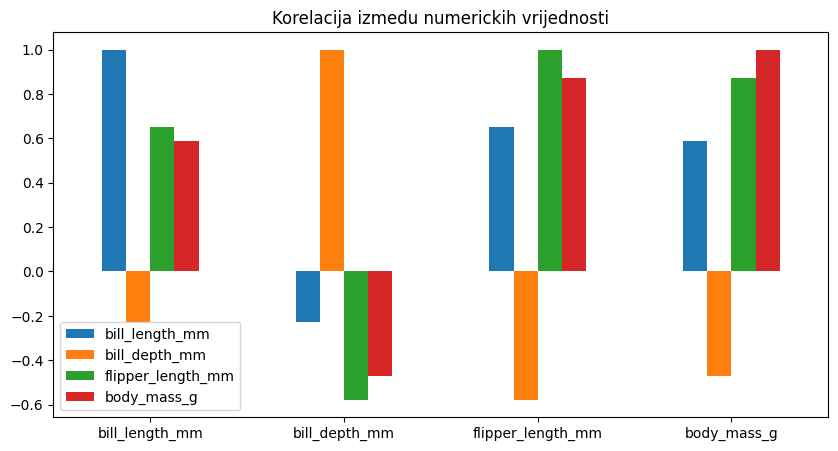

In [57]:
correlation_matrix.plot(
    kind='bar',
    figsize=(10, 5),
    title='Korelacija izmedu numerickih vrijednosti'
)

plt.xticks(rotation=0)